<a href="https://colab.research.google.com/github/RafihaikalP/Rafi-Haikal-Pratama_2411532002_ML_2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
# load dataset breast cancer
data = load_breast_cancer()

# ubah ke DataFrame agar mudah dilihat
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print(df.shape)
print(df['target'].value_counts())

(569, 31)
target
1    357
0    212
Name: count, dtype: int64


In [4]:
print(data.target_names)


['malignant' 'benign']


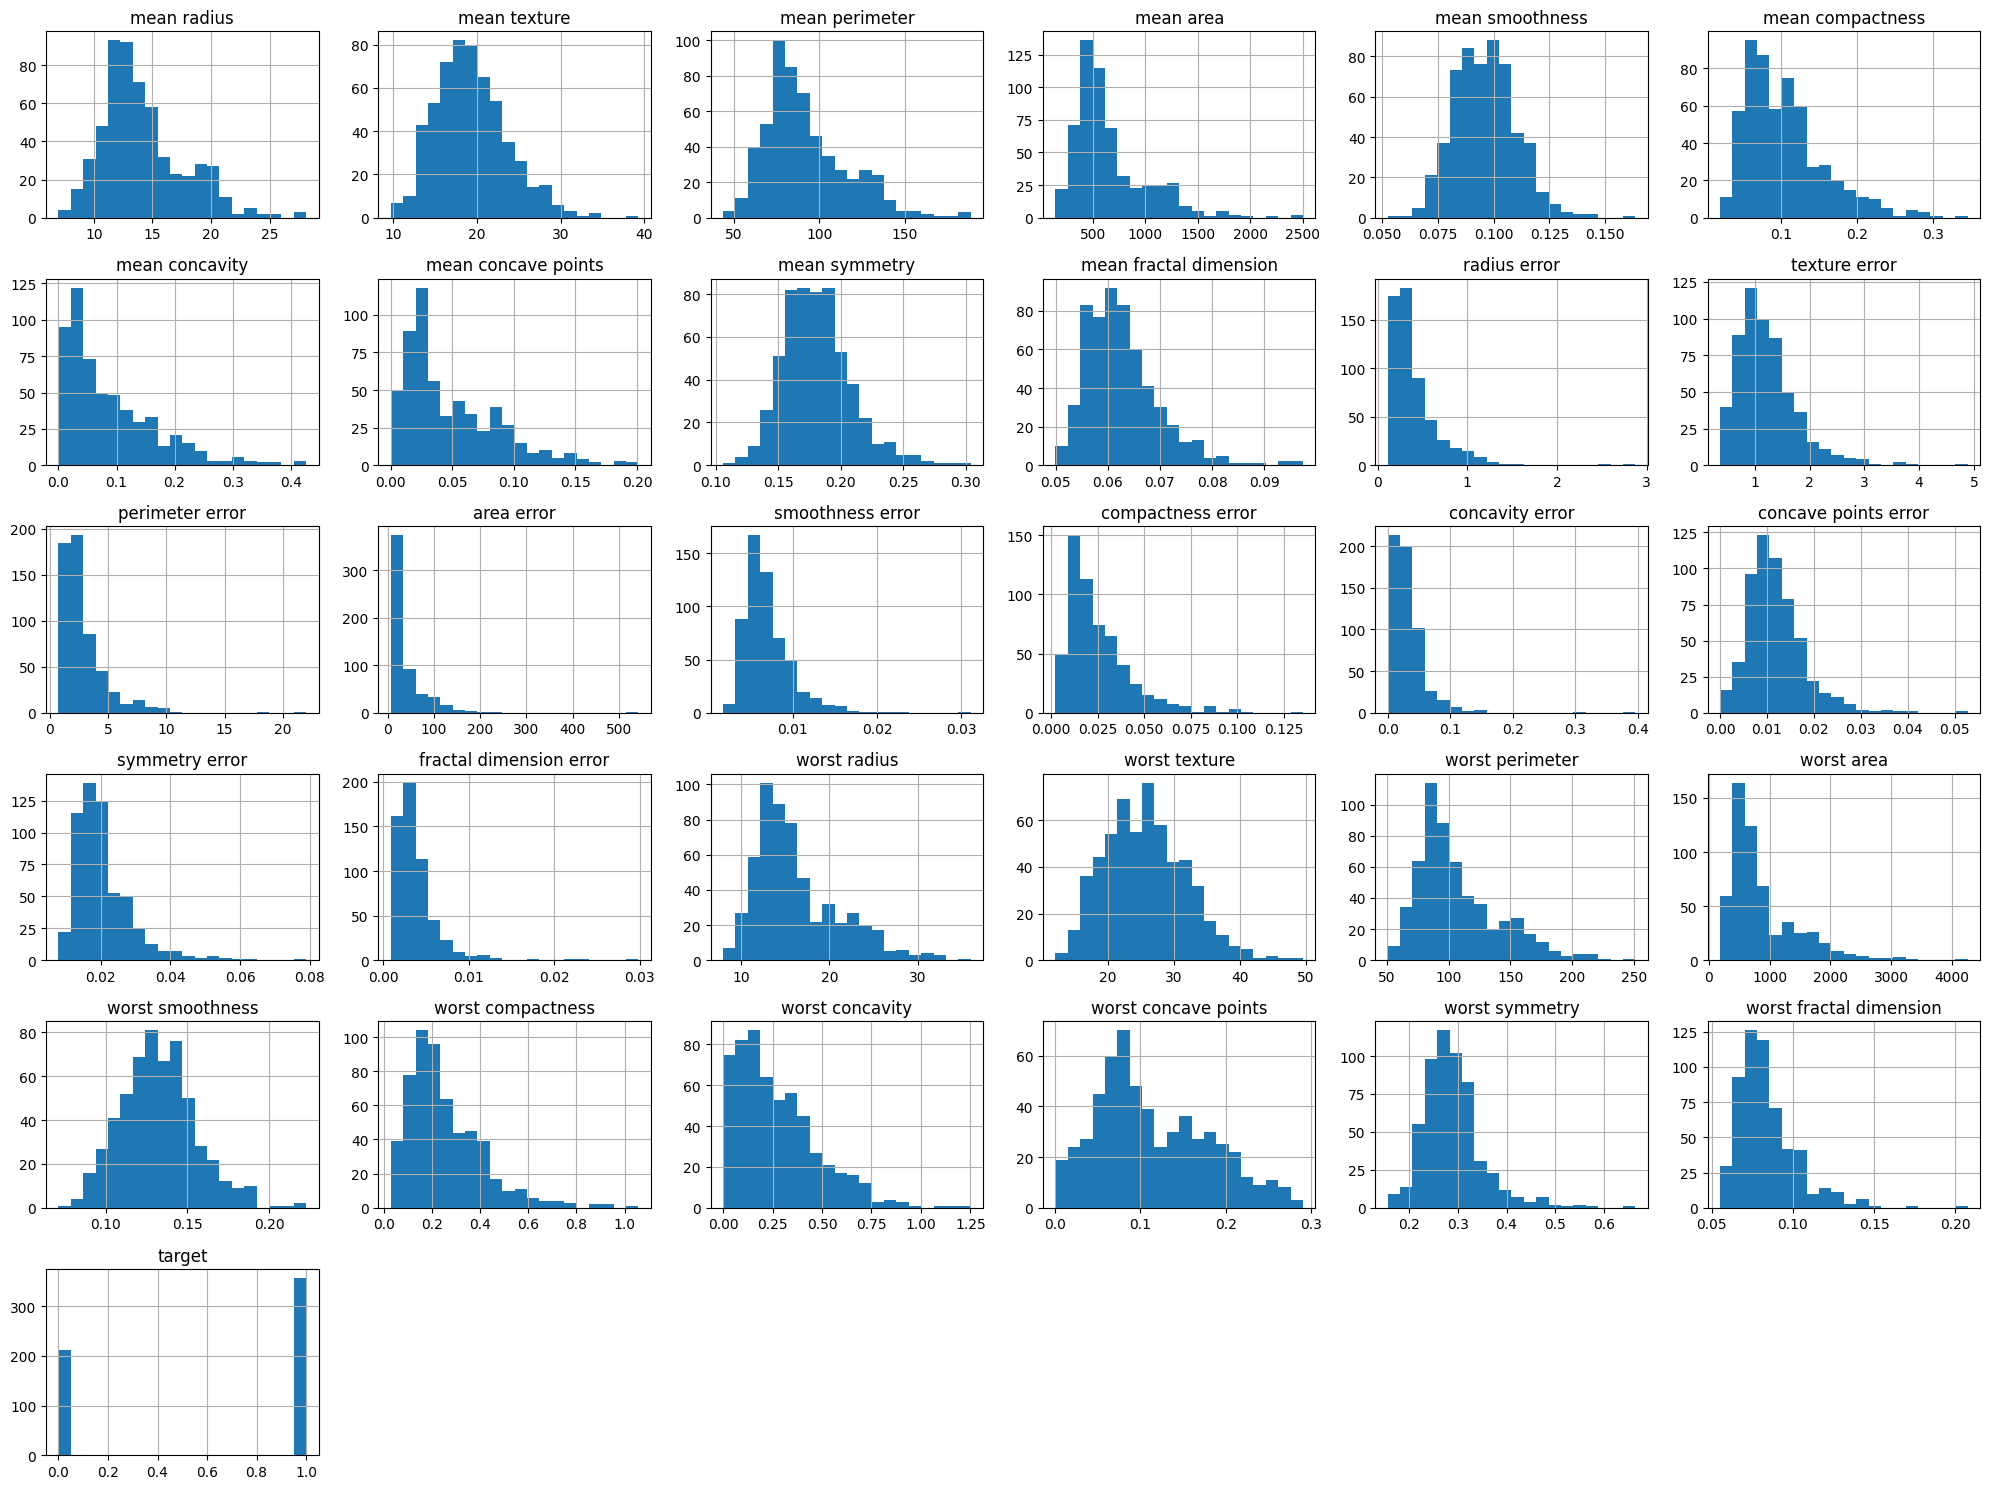

In [6]:
# histogram beberapa fitur
df.hist(figsize=(20, 15), bins=20)
plt.tight_layout()
plt.show()


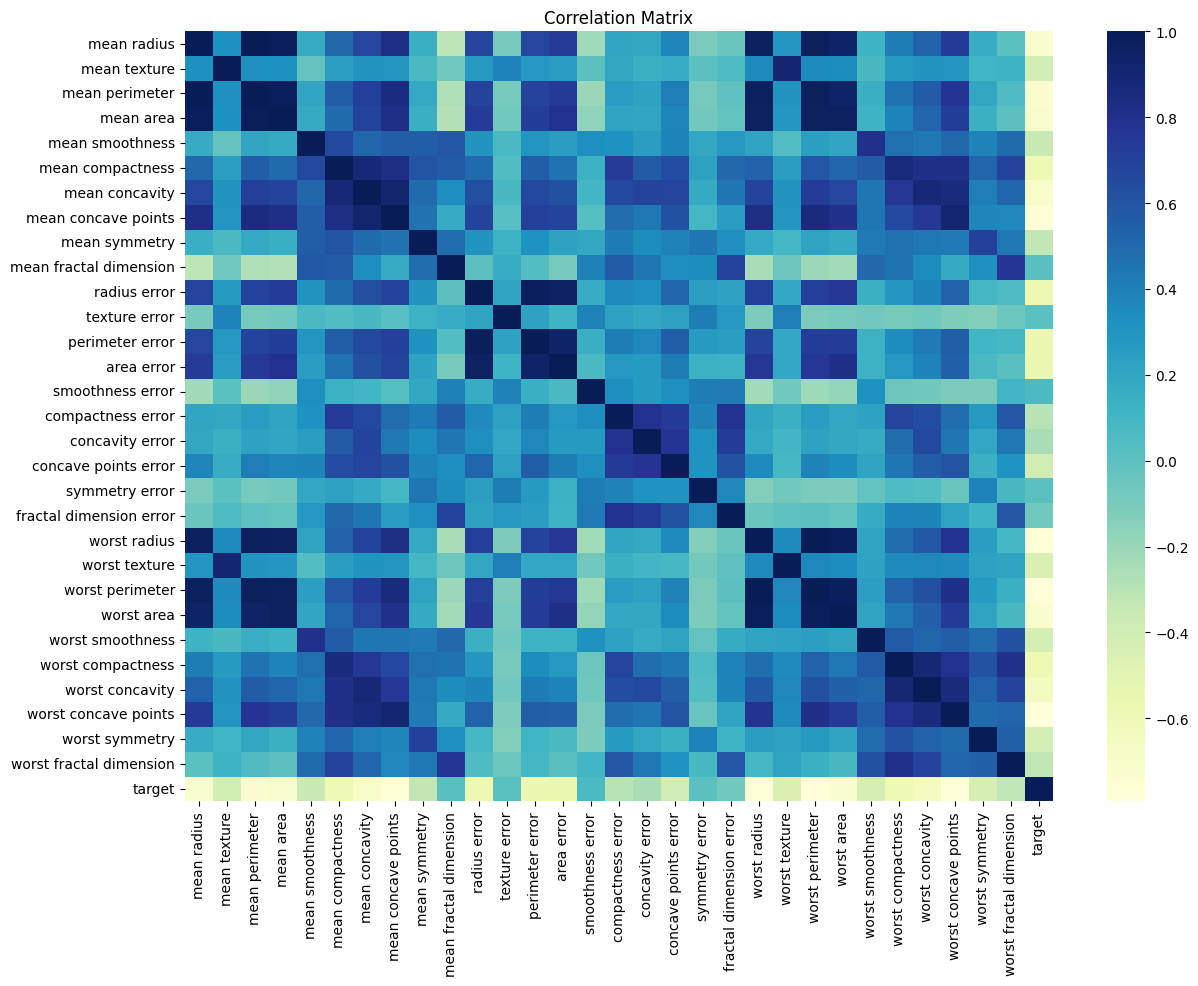

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='YlGnBu')
plt.title('Correlation Matrix')
plt.show()

In [8]:
# split dataset in features and target variable
X = df.drop('target', axis=1)   # Features
y = df['target']                # Target variable

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [9]:
# Split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=16, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(398, 30)
(171, 30)


In [10]:
# instantiate the model (without scaling)
logreg_no_scaling = LogisticRegression(max_iter=10000, random_state=16)

# fit the model with data
logreg_no_scaling.fit(X_train, y_train)

# prediksi default threshold 0.5
y_pred_no_scaling = logreg_no_scaling.predict(X_test)
y_pred_proba_no_scaling = logreg_no_scaling.predict_proba(X_test)[:, 1]

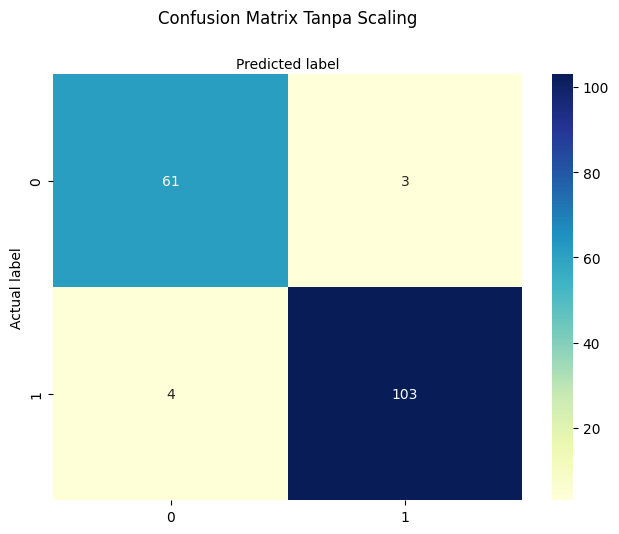

In [11]:
cnf_matrix_no_scaling = confusion_matrix(y_test, y_pred_no_scaling)
cnf_matrix_no_scaling

class_names = [0, 1]  # name of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix_no_scaling), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix Tanpa Scaling', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [12]:
target_names = ['malignant', 'benign']
print(classification_report(y_test, y_pred_no_scaling, target_names=target_names))

              precision    recall  f1-score   support

   malignant       0.94      0.95      0.95        64
      benign       0.97      0.96      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [13]:
acc_no_scaling = accuracy_score(y_test, y_pred_no_scaling)
prec_no_scaling = precision_score(y_test, y_pred_no_scaling)
rec_no_scaling = recall_score(y_test, y_pred_no_scaling)
f1_no_scaling = f1_score(y_test, y_pred_no_scaling)

print("Accuracy  :", acc_no_scaling)
print("Precision :", prec_no_scaling)
print("Recall    :", rec_no_scaling)
print("F1-Score  :", f1_no_scaling)


Accuracy  : 0.9590643274853801
Precision : 0.9716981132075472
Recall    : 0.9626168224299065
F1-Score  : 0.9671361502347418


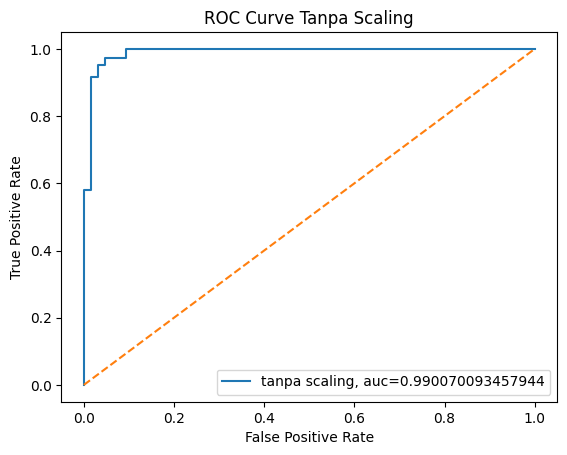

In [14]:
fpr_no_scaling, tpr_no_scaling, _ = roc_curve(y_test, y_pred_proba_no_scaling)
auc_no_scaling = roc_auc_score(y_test, y_pred_proba_no_scaling)

plt.plot(fpr_no_scaling, tpr_no_scaling, label="tanpa scaling, auc=" + str(auc_no_scaling))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend(loc=4)
plt.title("ROC Curve Tanpa Scaling")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# instantiate the model (with scaling)
logreg_scaling = LogisticRegression(max_iter=10000, random_state=16)

# fit the model with scaled data
logreg_scaling.fit(X_train_scaled, y_train)

# prediksi default threshold 0.5
y_pred_scaling = logreg_scaling.predict(X_test_scaled)
y_pred_proba_scaling = logreg_scaling.predict_proba(X_test_scaled)[:, 1]

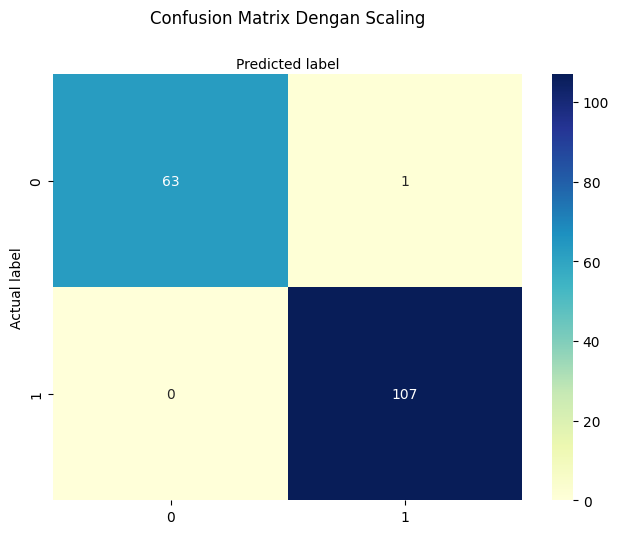

In [17]:
cnf_matrix_scaling = confusion_matrix(y_test, y_pred_scaling)
cnf_matrix_scaling

class_names = [0, 1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix_scaling), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix Dengan Scaling', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [18]:
target_names = ['malignant', 'benign']
print(classification_report(y_test, y_pred_scaling, target_names=target_names))

              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        64
      benign       0.99      1.00      1.00       107

    accuracy                           0.99       171
   macro avg       1.00      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



In [19]:
acc_scaling = accuracy_score(y_test, y_pred_scaling)
prec_scaling = precision_score(y_test, y_pred_scaling)
rec_scaling = recall_score(y_test, y_pred_scaling)
f1_scaling = f1_score(y_test, y_pred_scaling)

print("Accuracy  :", acc_scaling)
print("Precision :", prec_scaling)
print("Recall    :", rec_scaling)
print("F1-Score  :", f1_scaling)

Accuracy  : 0.9941520467836257
Precision : 0.9907407407407407
Recall    : 1.0
F1-Score  : 0.9953488372093023


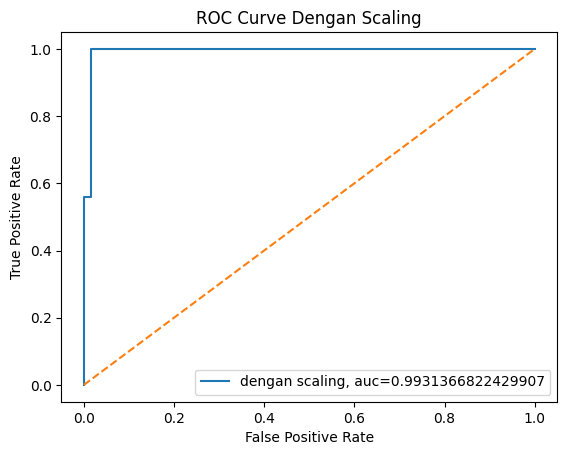

In [20]:
fpr_scaling, tpr_scaling, _ = roc_curve(y_test, y_pred_proba_scaling)
auc_scaling = roc_auc_score(y_test, y_pred_proba_scaling)

plt.plot(fpr_scaling, tpr_scaling, label="dengan scaling, auc=" + str(auc_scaling))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend(loc=4)
plt.title("ROC Curve Dengan Scaling")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [21]:
hasil_scaling = pd.DataFrame({
    'Model': ['Tanpa Scaling', 'Dengan Scaling'],
    'Accuracy': [acc_no_scaling, acc_scaling],
    'Precision': [prec_no_scaling, prec_scaling],
    'Recall': [rec_no_scaling, rec_scaling],
    'F1-Score': [f1_no_scaling, f1_scaling],
    'AUC': [auc_no_scaling, auc_scaling]
})

hasil_scaling

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Tanpa Scaling,0.959064,0.971698,0.962617,0.967136,0.990070
1,Dengan Scaling,0.994152,0.990741,1.000000,0.995349,0.993137


In [22]:
def evaluate_threshold(y_true, y_proba, threshold=0.5):
    y_pred_threshold = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred_threshold)
    prec = precision_score(y_true, y_pred_threshold)
    rec = recall_score(y_true, y_pred_threshold)
    f1 = f1_score(y_true, y_pred_threshold)
    cm = confusion_matrix(y_true, y_pred_threshold)

    return acc, prec, rec, f1, cm

In [23]:
threshold_list = [0.3, 0.4, 0.5, 0.6, 0.7]

hasil_threshold = []

for th in threshold_list:
    acc, prec, rec, f1, cm = evaluate_threshold(y_test, y_pred_proba_scaling, threshold=th)
    hasil_threshold.append([th, acc, prec, rec, f1])

df_threshold = pd.DataFrame(
    hasil_threshold,
    columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
)

df_threshold

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.3,0.988304,0.981651,1.000000,0.990741
1,0.4,0.988304,0.981651,1.000000,0.990741
2,0.5,0.994152,0.990741,1.000000,0.995349
3,0.6,0.976608,0.990476,0.971963,0.981132
4,0.7,0.970760,0.990385,0.962617,0.976303


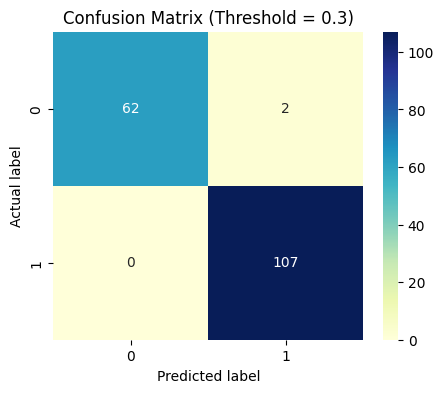

Threshold = 0.3
              precision    recall  f1-score   support

   malignant       1.00      0.97      0.98        64
      benign       0.98      1.00      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



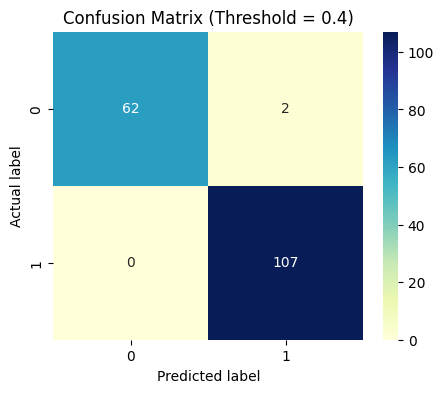

Threshold = 0.4
              precision    recall  f1-score   support

   malignant       1.00      0.97      0.98        64
      benign       0.98      1.00      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



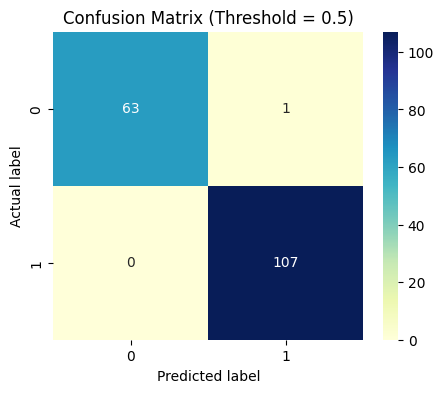

Threshold = 0.5
              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        64
      benign       0.99      1.00      1.00       107

    accuracy                           0.99       171
   macro avg       1.00      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



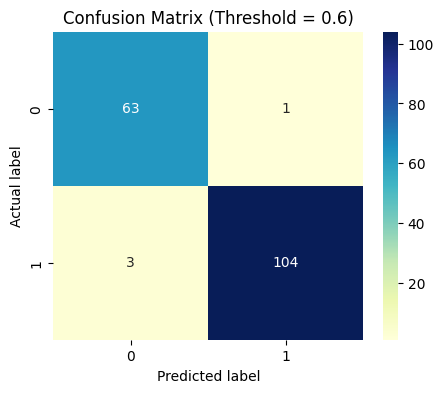

Threshold = 0.6
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.97        64
      benign       0.99      0.97      0.98       107

    accuracy                           0.98       171
   macro avg       0.97      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



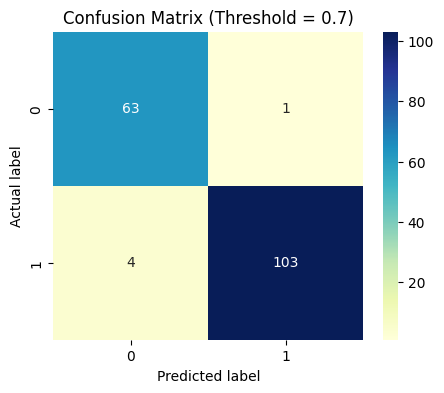

Threshold = 0.7
              precision    recall  f1-score   support

   malignant       0.94      0.98      0.96        64
      benign       0.99      0.96      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [24]:
for th in threshold_list:
    y_pred_th = (y_pred_proba_scaling >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)

    plt.figure(figsize=(5, 4))
    sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu", fmt='g')
    plt.title(f'Confusion Matrix (Threshold = {th})')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

    print(f"Threshold = {th}")
    print(classification_report(y_test, y_pred_th, target_names=['malignant', 'benign']))

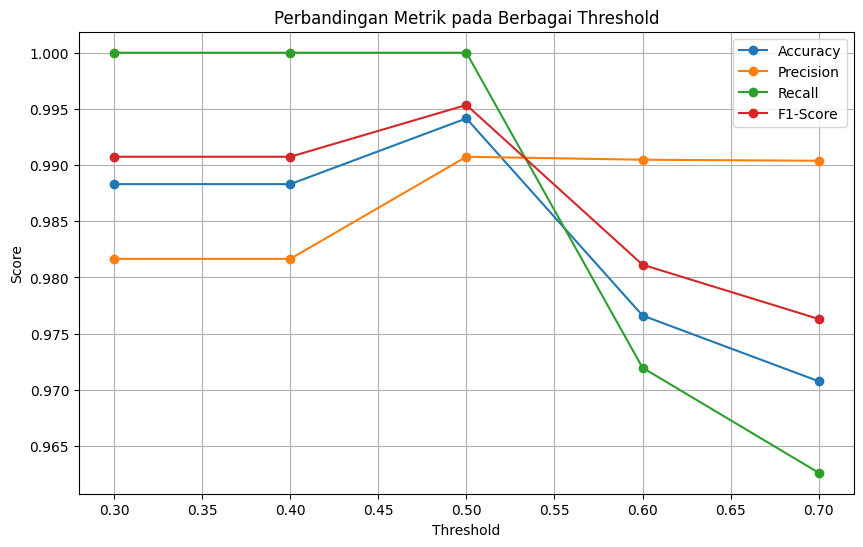

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(df_threshold['Threshold'], df_threshold['Accuracy'], marker='o', label='Accuracy')
plt.plot(df_threshold['Threshold'], df_threshold['Precision'], marker='o', label='Precision')
plt.plot(df_threshold['Threshold'], df_threshold['Recall'], marker='o', label='Recall')
plt.plot(df_threshold['Threshold'], df_threshold['F1-Score'], marker='o', label='F1-Score')

plt.title('Perbandingan Metrik pada Berbagai Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

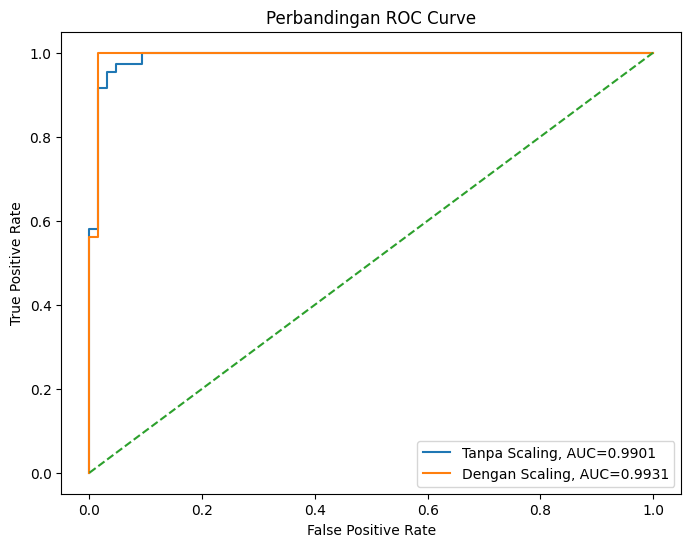

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_no_scaling, tpr_no_scaling, label='Tanpa Scaling, AUC=' + str(round(auc_no_scaling, 4)))
plt.plot(fpr_scaling, tpr_scaling, label='Dengan Scaling, AUC=' + str(round(auc_scaling, 4)))
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('Perbandingan ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()